# Chronos-2 — CATSA Train → EmpaticaE4 Test (EDA only)

**Model**: Amazon Chronos-2 (Chronos-T5-small, fine-tuning)
- 사전학습된 시계열 파운데이션 모델 (T5 기반, d_model=512)
- Channel-independent: EDA 단채널 인코딩
- 240→60 서브샘플링(÷4)으로 512 토큰 컨텍스트 제한에 맞춤
- 상위 Transformer 레이어 + 분류 헤드를 fine-tuning
- 참고: *Unified Training of Universal Time Series Forecasting Transformers* (Woo et al., 2024)

**학습**: CATSA 전체 피험자 (EDA 1채널, 4Hz)  
**평가**: EmpaticaE4Stress (subject_01 ~ subject_06)

---
**설치 필요**: `pip install chronos-forecasting`

In [14]:
import json, math, warnings
import numpy as np
import pandas as pd
from copy import deepcopy
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

TASKS        = ["Baseline", "Logic", "Nback", "Stroop", "Sudoku"]
STRESS_TASKS = {"Logic", "Nback", "Stroop", "Sudoku"}
EDA_FS       = 4

CATSA_ROOT  = Path("/home/binghin2/Myproject/Dataset/CATSA")
E4_ROOT     = Path("/home/binghin2/Myproject/Dataset/EmpaticaE4Stress/Subjects")
SUBJECTS_E4 = [f"subject_{i:02d}" for i in range(1, 7)]
SAVE_DIR    = Path("/home/binghin2/Myproject/Research/CATSA/Train/Individual_data/EDA/Save_model_Chronos2")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

def discover_subjects(root):
    out = []
    for d in sorted(root.glob("Sub*"), key=lambda p: int(p.name[3:])):
        if d.is_dir() and all((d / t / "EDA.csv").exists() for t in TASKS):
            out.append(d.name)
    return out

def read_eda(path):
    df   = pd.read_csv(path)
    cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    vals = df[cols[0]].to_numpy(np.float32) if cols else pd.to_numeric(df.iloc[:, 0], errors='coerce').to_numpy(np.float32)
    return vals[~np.isnan(vals)]

def make_windows(sig, W, S):
    if len(sig) < W: return np.empty((0, 1, W), np.float32)
    return np.asarray([sig[i:i+W] for i in range(0, len(sig)-W+1, S)], np.float32)[:, None, :]

def build_catsa_arrays(subjects, W, S):
    xs, ys = [], []
    for sub in subjects:
        path  = CATSA_ROOT / sub
        all_v = np.concatenate([read_eda(path / t / "EDA.csv") for t in TASKS])
        mu    = float(np.mean(all_v))
        sigma = float(np.std(all_v)) + 1e-8
        for task in TASKS:
            norm = (read_eda(path / task / "EDA.csv") - mu) / sigma
            w    = make_windows(norm, W, S)
            if len(w): xs.append(w); ys.append(np.full(len(w), int(task in STRESS_TASKS), np.int64))
    return np.concatenate(xs), np.concatenate(ys)

def build_e4_labels(n, fs=4):
    fixed_s = {"rest0":180,"task1":600,"rest1":120,"task2":300,"rest2":120,
               "task3":180,"rest3":120,"rest4":120,"task5":60,"rest5":120}
    total_fixed_s = sum(fixed_s.values())
    
    # 총 길이가 프로토콜보다 짧을 경우 task4_s를 음수가 아닌 0으로 처리
    task4_s = max(0, n // fs - total_fixed_s)
    
    segs = [("rest0",180,0), ("task1",600,1), ("rest1",120,-1), ("task2",300,1),
            ("rest2",120,-1), ("task3",180,1), ("rest3",120,-1), ("task4",task4_s,1),
            ("rest4",120,-1), ("task5",60,1), ("rest5",120,-1)]
    
    labels = np.full(n, -1, np.int64)
    cur = 0
    for _, dur_s, lab in segs:
        if dur_s <= 0:
            continue
        end = min(cur + dur_s * fs, n)
        if end > cur: 
            labels[cur:end] = lab
        cur = end
        if cur >= n: 
            break
            
    return labels, int(task4_s)

def e4_windows(eda, labels, W, S):
    mask  = labels >= 0
    mu    = float(np.mean(eda[mask])) if mask.any() else float(np.mean(eda))
    sigma = (float(np.std(eda[mask])) + 1e-8) if mask.any() else (float(np.std(eda)) + 1e-8)
    norm  = ((eda - mu) / sigma).astype(np.float32)
    xs, ys = [], []
    for i in range(0, len(norm) - W + 1, S):
        u = np.unique(labels[i:i+W])
        if len(u) == 1 and u[0] in (0,1): xs.append(norm[i:i+W]); ys.append(int(u[0]))
    if not xs: return np.empty((0,1,W), np.float32), np.empty(0, np.int64)
    return np.asarray(xs, np.float32)[:, None, :], np.asarray(ys, np.int64)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__(); self.gamma, self.alpha = gamma, alpha
    def forward(self, logits, y):
        y = y.float()
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        pt  = torch.sigmoid(logits)*y + (1-torch.sigmoid(logits))*(1-y)
        fl  = (1-pt).pow(self.gamma)*bce
        if self.alpha is not None: fl = (self.alpha*y+(1-self.alpha)*(1-y))*fl
        return fl.mean()

def make_loader(x, y, bs, shuffle):
    return DataLoader(TensorDataset(torch.from_numpy(x), torch.from_numpy(y).float()),
                      batch_size=bs, shuffle=shuffle)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval(); tot=n=tp=tn=fp=fn=0
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE); lg=model(xb)
        tot+=criterion(lg,yb).item()*len(xb); n+=len(xb)
        pred=(torch.sigmoid(lg)>=0.5).long(); yi=yb.long()
        tp+=int(((pred==1)&(yi==1)).sum()); tn+=int(((pred==0)&(yi==0)).sum())
        fp+=int(((pred==1)&(yi==0)).sum()); fn+=int(((pred==0)&(yi==1)).sum())
    acc=(tp+tn)/max(n,1); pre=tp/max(tp+fp,1); rec=tp/max(tp+fn,1)
    return {"loss":tot/max(n,1),"accuracy":acc,"f1":2*pre*rec/max(pre+rec,1e-8),
            "precision":pre,"recall":rec,"tp":tp,"tn":tn,"fp":fp,"fn":fn}

def train_epoch_chronos(model, loader, optimizer, criterion):
    """Train epoch — gradients flow through Chronos encoder."""
    model.train(); tot=n=0
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss=criterion(model(xb),yb); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        tot+=loss.item()*len(xb); n+=len(xb)
    return tot/max(n,1)

print("Utilities loaded.")

Device: cuda
Utilities loaded.


In [15]:
# ── Chronos-2 Model ───────────────────────────────────────────────────────
from chronos import ChronosPipeline

print("Loading pretrained Chronos-T5-small...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",          # load weights on CPU first
    torch_dtype=torch.float32,
)
print(f"Chronos context_length : {pipeline.model_context_length}")
print(f"T5 d_model             : {pipeline.model.model.config.d_model}")
print(f"T5 encoder layers      : {pipeline.model.model.config.num_layers}")


class Chronos2Classifier(nn.Module):
    """
    Chronos-2 stress classifier for EDA (univariate).

    Pipeline:
      x [B,1,240]  →  subsample ÷4  →  [B,1,60]
      x[:,0,:]  →  MeanScaleUniformBins tokenizer  →  T5 encoder  →  mean pool  →  [B, 512]
      → classification head  →  [B]

    Training strategy:
      - Bottom 4/6 T5 encoder layers frozen (pretrained representations preserved)
      - Top 2 layers + classification head fine-tuned
    """
    def __init__(self, chronos_pipeline, subsample: int = 4, dropout: float = 0.3):
        super().__init__()
        self.subsample  = subsample
        self.tokenizer  = chronos_pipeline.tokenizer
        self.chron_model= chronos_pipeline.model        # ChronosModel
        d_model         = chronos_pipeline.model.model.config.d_model  # 512

        # Freeze bottom 4 of 6 encoder blocks
        n_total = len(chronos_pipeline.model.model.encoder.block)
        n_freeze= max(0, n_total - 2)
        for i, blk in enumerate(chronos_pipeline.model.model.encoder.block):
            if i < n_freeze:
                for p in blk.parameters():
                    p.requires_grad = False
        print(f"Frozen {n_freeze}/{n_total} encoder blocks. Fine-tuning top {n_total-n_freeze}.")

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def _encode_channel(self, ch: torch.Tensor) -> torch.Tensor:
        # ch: [B, L]  — single-axis time series
        device = ch.device
        # Tokenise on CPU (quantisation is not differentiable, but gradients
        # flow through the T5 embedding table and encoder layers)
        token_ids, attn_mask, _ = self.tokenizer.context_input_transform(ch.detach().cpu())
        token_ids = token_ids.to(device)
        attn_mask = attn_mask.to(device)
        # Encode — gradient flows through T5 encoder
        enc = self.chron_model.encode(
            input_ids=token_ids, attention_mask=attn_mask
        )  # [B, seq_len, d_model]
        # Masked mean pool
        mask_f = attn_mask.unsqueeze(-1).float()
        emb = (enc * mask_f).sum(1) / mask_f.sum(1).clamp(min=1)  # [B, d_model]
        return emb

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, 1, 240]
        x_sub = x[:, :, ::self.subsample]        # [B, 1, 60]
        emb = self._encode_channel(x_sub.squeeze(1))  # [B, d_model]
        return self.head(emb).squeeze(-1)  # [B]


model = Chronos2Classifier(pipeline).to(DEVICE)
x_dummy = torch.randn(2, 1, 240)
out_test = model(x_dummy.to(DEVICE))
print(f"\nInput: {x_dummy.shape}  Output: {out_test.shape}")
n_params_total  = sum(p.numel() for p in model.parameters())
n_params_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {n_params_total:,}")
print(f"Trainable params: {n_params_train:,}")
del x_dummy, out_test

Loading pretrained Chronos-T5-small...
Chronos context_length : 512
T5 d_model             : 512
T5 encoder layers      : 6
Frozen 4/6 encoder blocks. Fine-tuning top 2.

Input: torch.Size([2, 1, 240])  Output: torch.Size([2])
Total params:     46,303,105
Trainable params: 33,715,841


In [16]:
# ── Hyperparameters & Training on CATSA ──────────────────────────────────
HP = {
    "seed"       : 42,
    "val_ratio"  : 0.10,
    "window_size": EDA_FS * 60,   # 240
    "stride"     : EDA_FS * 10,   # 40
    "batch_size" : 32,            # smaller due to large model
    "epochs"     : 30,            # fewer epochs for pretrained model
    "lr"         : 5e-5,          # smaller lr for fine-tuning
    "wd"         : 1e-4,
    "patience"   : 6,
    "subsample"  : 4,             # 240 → 60
    "dropout"    : 0.3,
}

np.random.seed(HP["seed"]); torch.manual_seed(HP["seed"])
if torch.cuda.is_available(): torch.cuda.manual_seed_all(HP["seed"])

subjects  = discover_subjects(CATSA_ROOT)
print(f"Total CATSA subjects: {len(subjects)}")

rng       = np.random.default_rng(HP["seed"])
idx       = rng.permutation(len(subjects))
n_val     = max(4, int(len(subjects) * HP["val_ratio"]))
val_subs  = [subjects[i] for i in sorted(idx[:n_val])]
train_subs= [subjects[i] for i in sorted(idx[n_val:])]
print(f"Train: {len(train_subs)} | Val: {len(val_subs)}")

W, S = HP["window_size"], HP["stride"]
print("Building training arrays...")
x_train, y_train = build_catsa_arrays(train_subs, W, S)
x_val,   y_val   = build_catsa_arrays(val_subs,   W, S)
print(f"Train: {x_train.shape}  Val: {x_val.shape}")

loader_tr = make_loader(x_train, y_train, HP["batch_size"], True)
loader_va = make_loader(x_val,   y_val,   HP["batch_size"], False)

pos       = float(y_train.sum())
alpha     = float((len(y_train) - pos) / len(y_train))
criterion = FocalLoss(gamma=2.0, alpha=alpha).to(DEVICE)

# Separate lr for encoder vs head (lower lr for encoder)
encoder_params = list(model.chron_model.parameters())
head_params    = list(model.head.parameters())
optimizer = torch.optim.Adam([
    {"params": [p for p in encoder_params if p.requires_grad], "lr": HP["lr"] * 0.1},
    {"params": head_params,                                     "lr": HP["lr"]},
], weight_decay=HP["wd"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=3)

best_val_loss = float("inf"); best_state = None; wait = 0; history = []

for epoch in range(1, HP["epochs"] + 1):
    tr_loss = train_epoch_chronos(model, loader_tr, optimizer, criterion)
    val_m   = evaluate(model, loader_va, criterion)
    scheduler.step(val_m["loss"])
    history.append({"epoch":epoch,"train_loss":tr_loss,"val_loss":val_m["loss"],"val_f1":val_m["f1"]})
    if val_m["loss"] < best_val_loss:
        best_val_loss = val_m["loss"]; best_epoch = epoch; wait = 0
        best_state = deepcopy(model.state_dict())
        torch.save({"model_state_dict":best_state,"hp":HP,"epoch":epoch},
                   SAVE_DIR / "best_model.pt")
    else:
        wait += 1
        if wait >= HP["patience"]:
            print(f"Early stopping at epoch {epoch} (best: {best_epoch})"); break
    if epoch % 5 == 0 or epoch == 1:
        print(f"[{epoch:3d}] train={tr_loss:.4f}  val={val_m['loss']:.4f}  "
              f"f1={val_m['f1']:.4f}")

model.load_state_dict(best_state)
print(f"\nTraining complete. Best epoch: {best_epoch}, best_val_loss: {best_val_loss:.4f}")

Total CATSA subjects: 50
Train: 45 | Val: 5
Building training arrays...
Train: (2925, 1, 240)  Val: (325, 1, 240)
[  1] train=0.0485  val=0.0393  f1=0.8315
[  5] train=0.0402  val=0.0325  f1=0.8264
[ 10] train=0.0376  val=0.0318  f1=0.8442
[ 15] train=0.0348  val=0.0330  f1=0.8828
Early stopping at epoch 18 (best: 12)

Training complete. Best epoch: 12, best_val_loss: 0.0315


In [17]:
# ── Evaluate on EmpaticaE4Stress ──────────────────────────────────────────
model.eval()
all_true, all_pred = [], []
rows = []

for sub in SUBJECTS_E4:
    eda = read_eda(E4_ROOT / sub / "EDA.csv")
    labels, task4_sec = build_e4_labels(len(eda))
    x, y_true = e4_windows(eda, labels, W, S)
    if len(x) == 0:
        rows.append({"subject":sub,"n_windows":0,"accuracy":float("nan"),
                     "f1":float("nan"),"precision":float("nan"),"recall":float("nan")})
        continue
    with torch.no_grad():
        # Process in smaller batches to avoid OOM
        y_pred_all = []
        for i in range(0, len(x), 16):
            xb = torch.from_numpy(x[i:i+16]).to(DEVICE)
            lg = model(xb)
            y_pred_all.append((torch.sigmoid(lg) >= 0.5).cpu().numpy().astype(int))
        y_pred = np.concatenate(y_pred_all)
    rows.append({
        "subject":sub, "task4_sec":task4_sec, "n_windows":len(y_true),
        "accuracy":float(accuracy_score(y_true,y_pred)),
        "f1":float(f1_score(y_true,y_pred,zero_division=0)),
        "precision":float(precision_score(y_true,y_pred,zero_division=0)),
        "recall":float(recall_score(y_true,y_pred,zero_division=0)),
    })
    all_true.extend(y_true.tolist()); all_pred.extend(y_pred.tolist())

result_df = pd.DataFrame(rows)
print("=== Per-subject metrics ===")
display(result_df)

if all_true:
    ov_acc  = accuracy_score(all_true, all_pred)
    ov_f1   = f1_score(all_true, all_pred, zero_division=0)
    ov_prec = precision_score(all_true, all_pred, zero_division=0)
    ov_rec  = recall_score(all_true, all_pred, zero_division=0)
    print(f"\n=== Overall ===")
    print(f"Accuracy : {ov_acc:.4f}")
    print(f"F1       : {ov_f1:.4f}")
    print(f"Precision: {ov_prec:.4f}")
    print(f"Recall   : {ov_rec:.4f}")
    cm = confusion_matrix(all_true, all_pred)
    print("\nConfusion Matrix:"); print(cm)
    print("\n", classification_report(all_true, all_pred,
                                     target_names=["Non-stress","Stress"], zero_division=0))

=== Per-subject metrics ===


,subject,task4_sec,n_windows,accuracy,f1,precision,recall
0,subject_01,584,159,0.981132,0.989619,1.000000,0.979452
1,subject_02,434,144,0.569444,0.693069,0.985915,0.534351
2,subject_03,0,75,0.920000,0.951613,0.951613,0.951613
3,subject_04,0,106,0.886792,0.931034,1.000000,0.870968
4,subject_05,163,117,0.897436,0.938776,1.000000,0.884615
5,subject_06,0,68,0.911765,0.946429,0.929825,0.963636



=== Overall ===
Accuracy : 0.8490
F1       : 0.9079
Precision: 0.9842
Recall   : 0.8426

Confusion Matrix:
[[ 70   8]
 [ 93 498]]

               precision    recall  f1-score   support

  Non-stress       0.43      0.90      0.58        78
      Stress       0.98      0.84      0.91       591

    accuracy                           0.85       669
   macro avg       0.71      0.87      0.74       669
weighted avg       0.92      0.85      0.87       669



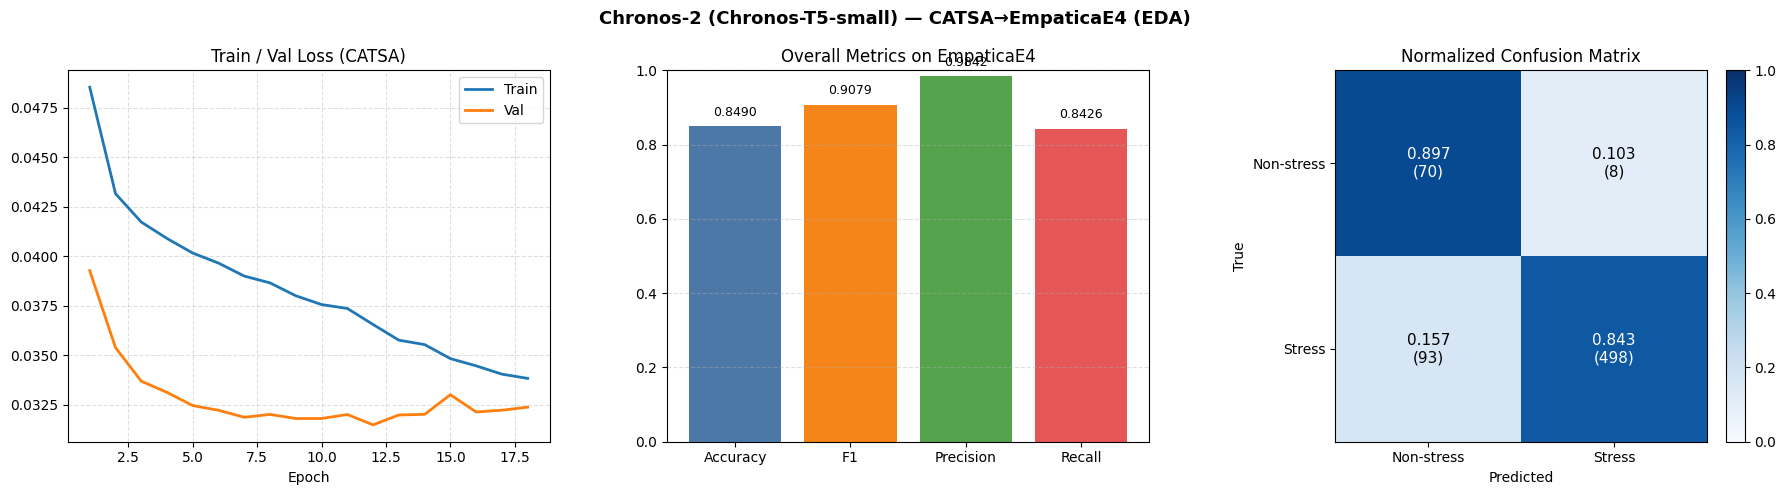

Saved results.png


In [18]:
# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_list = [h["epoch"] for h in history]
axes[0].plot(epochs_list, [h["train_loss"] for h in history], label="Train", linewidth=2)
axes[0].plot(epochs_list, [h["val_loss"]   for h in history], label="Val",   linewidth=2)
axes[0].set_title("Train / Val Loss (CATSA)"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(linestyle="--", alpha=0.4)

if all_true:
    bars = axes[1].bar(["Accuracy","F1","Precision","Recall"],
                       [ov_acc, ov_f1, ov_prec, ov_rec],
                       color=["#4C78A8","#F58518","#54A24B","#E45756"])
    axes[1].set_ylim(0, 1.0); axes[1].set_title("Overall Metrics on EmpaticaE4")
    axes[1].grid(axis="y", linestyle="--", alpha=0.4)
    for b, v in zip(bars, [ov_acc, ov_f1, ov_prec, ov_rec]):
        axes[1].text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.4f}",
                     ha="center", va="bottom", fontsize=9)

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    im = axes[2].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    axes[2].set_title("Normalized Confusion Matrix")
    axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
    axes[2].set_xticklabels(["Non-stress","Stress"])
    axes[2].set_yticklabels(["Non-stress","Stress"])
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
    thr = cm_norm.max() / 2
    for i in range(2):
        for j in range(2):
            axes[2].text(j, i, f"{cm_norm[i,j]:.3f}\n({cm[i,j]})",
                         ha="center", va="center",
                         color="white" if cm_norm[i,j] > thr else "black", fontsize=11)
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle("Chronos-2 (Chronos-T5-small) — CATSA→EmpaticaE4 (EDA)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results.png")